# AC 4.1.0 实验对比

对比同一 `AC_MODE` + `MODEL` 下，不同 **agent**、**top_k** 与 **TO_SELECT** 的：
- **Type Acc / Step Acc / SR**：`命中率 (命中数/总数)`，如 `93.92% (494/526)`、`53.00% (53/100)`
- **Top-K Retrieval**（仅表格）：同上格式；CPM 等无检索步为 `N/A`

运行文件命名：
- m2 / m2v / TO：`runs/{AC_MODE}_{agent}_top{top_k}{to_select}_{MODEL}.json`（如 `low_m2_top5generate_kimi-k2.6.json`）
- CPM（无 top_k / to_select）：`runs/{AC_MODE}_CPM_{MODEL}.json`

In [4]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

from eval.compare_runs import collect_comparison

# ========== 全局配置 ==========
AC_MODE = "low"
# AC_MODE = "high"          # "low" | "high"
MODEL = "qwen-vl-max"     # 与 runs 文件名末尾的 vlm_model 一致
# MODEL = "kimi-k2.6"
# TO_SELECT 过滤：None=同 MODEL 下全部 to_select 一并对比（含 TO_top1best 等）
# 也可设为 "generate" 或 ["generate", "best"]
TO_SELECT = None
# ==============================

PROJECT_ROOT = Path(".").resolve()
RUNS_DIR = PROJECT_ROOT / "runs"

plt.rcParams["font.sans-serif"] = ["Arial Unicode MS", "PingFang SC", "SimHei", "DejaVu Sans"]
plt.rcParams["axes.unicode_minus"] = False

In [5]:
rows = collect_comparison(AC_MODE, MODEL, RUNS_DIR, to_select=TO_SELECT)

if not rows:
    raise FileNotFoundError(
        f"未找到匹配的 runs 文件: {RUNS_DIR}/{AC_MODE}_*_top*{TO_SELECT or ''}_{MODEL}.json "
        f"或 {RUNS_DIR}/{AC_MODE}_CPM_{MODEL}.json"
    )

df = pd.DataFrame(rows)
display_df = df[
    [
        "label",
        "agent",
        "top_k",
        "to_select",
        "episodes",
        "steps",
        "type_acc",
        "step_acc",
        "sr",
        "topk_retrieval",
        "run_file",
    ]
].copy()

display_df["top_k"] = display_df["top_k"].map(lambda x: "" if pd.isna(x) or x is None else x)

def _fmt_rate(rate, correct: int, total: int) -> str:
    if total is None or total == 0 or rate is None or (isinstance(rate, float) and pd.isna(rate)):
        return "N/A"
    return f"{rate:.2%} ({int(correct)}/{int(total)})"

display_df["type_acc"] = df.apply(
    lambda r: _fmt_rate(r["type_acc"], r["type_correct"], r["steps"]), axis=1
)
display_df["step_acc"] = df.apply(
    lambda r: _fmt_rate(r["step_acc"], r["step_correct"], r["steps"]), axis=1
)
display_df["sr"] = df.apply(
    lambda r: _fmt_rate(r["sr"], r["sr_correct"], r["episodes"]), axis=1
)
display_df["topk_retrieval"] = df.apply(
    lambda r: _fmt_rate(r["topk_retrieval"], r["retrieval_correct"], r["retrieval_eligible"])
    if r.get("retrieval_eligible")
    else "N/A",
    axis=1,
)

filter_note = ""
if TO_SELECT is None:
    filter_note = " | TO_SELECT=全部"
elif isinstance(TO_SELECT, str):
    filter_note = f" | TO_SELECT={TO_SELECT}"
else:
    filter_note = f" | TO_SELECT={','.join(TO_SELECT)}"
print(f"AC_MODE={AC_MODE} | MODEL={MODEL}{filter_note} | 配置数={len(df)}")
display_df

AC_MODE=low | MODEL=qwen-vl-max | TO_SELECT=全部 | 配置数=8


,label,agent,top_k,to_select,episodes,steps,type_acc,step_acc,sr,topk_retrieval,run_file
0,CPM,CPM,,None,50,257,93.39% (240/257),84.82% (218/257),58.00% (29/50),N/A,low_CPM_qwen-vl-max.json
1,TO_top1best,TO,1.0,best,50,257,94.16% (242/257),84.44% (217/257),54.00% (27/50),90.32% (140/155),low_TO_top1best_qwen-vl-max.json
2,TOa_top1best,TOa,1.0,best,50,257,94.55% (243/257),85.21% (219/257),58.00% (29/50),88.48% (146/165),low_TOa_top1best_qwen-vl-max.json
3,m12_top5best,m12,5.0,best,50,257,94.94% (244/257),89.88% (231/257),64.00% (32/50),97.58% (161/165),low_m12_top5best_qwen-vl-max.json
4,m12_top5generate,m12,5.0,generate,50,257,96.11% (247/257),88.72% (228/257),58.00% (29/50),92.12% (152/165),low_m12_top5generate_qwen-vl-max.json
5,m2_top5best,m2,5.0,best,50,257,95.33% (245/257),87.94% (226/257),58.00% (29/50),97.58% (161/165),low_m2_top5best_qwen-vl-max.json
6,m2_top5generate,m2,5.0,generate,50,257,95.33% (245/257),87.94% (226/257),58.00% (29/50),92.73% (153/165),low_m2_top5generate_qwen-vl-max.json
7,m2v_top5generate,m2v,5.0,generate,50,257,94.55% (243/257),87.55% (225/257),60.00% (30/50),92.12% (152/165),low_m2v_top5generate_qwen-vl-max.json


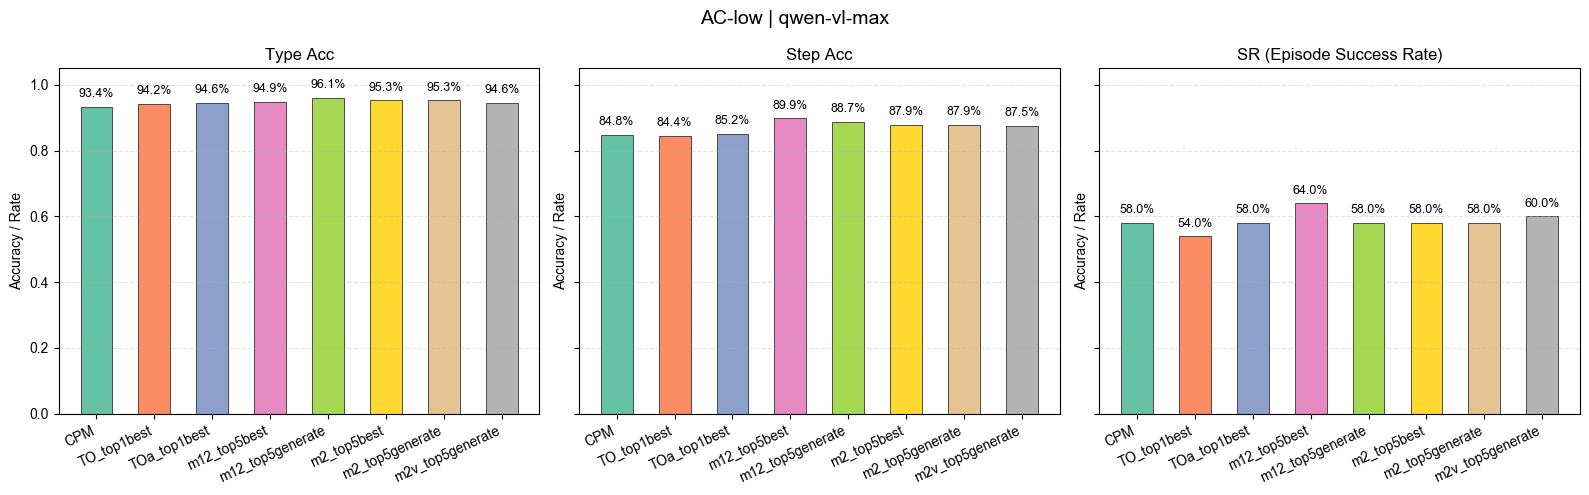

In [6]:
plot_df = pd.DataFrame(rows)
x_labels = plot_df["label"].tolist()
x_pos = range(len(x_labels))
bar_width = 0.55
colors = plt.cm.Set2(range(len(x_labels)))

metrics = [
    ("type_acc", "Type Acc"),
    ("step_acc", "Step Acc"),
    ("sr", "SR (Episode Success Rate)"),
]

fig, axes = plt.subplots(1, 3, figsize=(16, 5), sharey=True)
fig.suptitle(f"AC-{AC_MODE} | {MODEL}", fontsize=14, fontweight="bold")

for ax, (col, title) in zip(axes, metrics):
    values = plot_df[col].tolist()
    bars = ax.bar(x_pos, values, width=bar_width, color=colors, edgecolor="#333333", linewidth=0.6)
    ax.set_title(title, fontsize=12)
    ax.set_xticks(list(x_pos))
    ax.set_xticklabels(x_labels, rotation=25, ha="right")
    ax.set_ylim(0, 1.05)
    ax.set_ylabel("Accuracy / Rate")
    ax.grid(axis="y", linestyle="--", alpha=0.35)
    for bar, val in zip(bars, values):
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 0.02,
            f"{val:.1%}",
            ha="center",
            va="bottom",
            fontsize=9,
        )

plt.tight_layout()
plt.show()